## Semi-Supervised Learning with Conformal Prediction

**Approach Overview:**  
In this notebook, we implement a semi-supervised learning strategy for predicting hardness using a PCA-reduced feature set. The core idea is to iteratively expand the labeled dataset by adding predictions on unlabeled samples that the model is confident about.  

To quantify prediction confidence, we use **MAPIE (Model Agnostic Prediction Interval Estimator)**, which generates **conformal prediction intervals**. These intervals provide a statistically valid range for each prediction, capturing model uncertainty in a principled way.  

**Why this approach is a good idea:**

1. **Small labeled dataset:** Our initial dataset is very limited (~138 samples), making traditional supervised learning prone to overfitting. By selectively adding high-confidence predictions to the labeled set, we can leverage the larger unlabeled pool without introducing too much noise.

2. **Uncertainty-aware selection:** Instead of blindly trusting model predictions, we only admit predictions where the conformal interval is narrow relative to the predicted value (relative interval width). This ensures that we expand the labeled set with samples the model is most certain about, improving robustness.


3. **Statistical guarantees:** Conformal prediction intervals provide a formal guarantee that the true target value lies within the interval with a specified confidence level (e.g., 90%). This adds rigor compared to arbitrary thresholds or heuristics.

Overall, this approach balances **exploiting the unlabeled data** while controlling for **prediction uncertainty**, which is crucial when working with small, high-dimensional datasets like ours.


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from mapie.regression import SplitConformalRegressor
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns



In [21]:
# -------------------------------
# Paths
# -------------------------------
os.makedirs('trained_models', exist_ok=True)
pca_model_path = 'pca_model/pca_model.pkl'
imputer_path = 'pca_model/imputer.pkl'
full_data_path = '../../welddatabase/welddb_pca.csv'

In [22]:
# -------------------------------
# Load full dataset
# -------------------------------
df = pd.read_csv(full_data_path)

# Separate labeled and unlabeled samples
df_labeled = df[df['Hardness_kg_mm2'].notna()].copy()
df_unlabeled = df[df['Hardness_kg_mm2'].isna()].copy()

y_labeled = df_labeled['Hardness_kg_mm2']
target_columns = ['Yield_Strength_MPa', 'UTS_MPa', 'Elongation_%', 
                  'Reduction_Area_%', 'Charpy_Temp_C', 'Charpy_Energy_J',
                  'Hardness_kg_mm2', 'FATT_50%', 'Primary_Ferrite_%',
                  'Ferrite_2nd_Phase_%', 'Acicular_Ferrite_%', 'Martensite_%',
                  'Ferrite_Carbide_%']

X_labeled = df_labeled.drop(columns=target_columns)

X_unlabeled = df_unlabeled.drop(columns=target_columns)

In [23]:
# -------------------------------
# Load PCA and imputer pipeline
# -------------------------------
pca = joblib.load(pca_model_path)
imputer = joblib.load(imputer_path)

# Transform features
X_labeled_imputed = imputer.transform(X_labeled)
X_labeled_pca = pca.transform(X_labeled_imputed)

X_unlabeled_imputed = imputer.transform(X_unlabeled)
X_unlabeled_pca = pca.transform(X_unlabeled_imputed)

# Convert back to DataFrame
pc_columns = [f'PC{i+1}' for i in range(X_labeled_pca.shape[1])]
X_labeled_pca_df = pd.DataFrame(X_labeled_pca, columns=pc_columns)
X_unlabeled_pca_df = pd.DataFrame(X_unlabeled_pca, columns=pc_columns)

In [24]:
# -------------------------------
# Model hyperparameters
# -------------------------------
best_params = {
    'learning_rate': 0.05,
    'max_depth': 4,
    'min_samples_split': 5,
    'n_estimators': 400,
    'subsample': 0.9
}

In [25]:
# -------------------------------
# Semi-supervised iterative learning
# -------------------------------
max_iterations = 5
relative_threshold = 0.1  # 10% relative interval width
iteration = 0

X_labeled_current = X_labeled_pca_df.copy()
y_labeled_current = y_labeled.copy()
X_unlabeled_current = X_unlabeled_pca_df.copy()

In [27]:
while iteration < max_iterations and not X_unlabeled_current.empty:
    iteration += 1
    print(f"\n--- Iteration {iteration} ---")

    # Train model
    model = GradientBoostingRegressor(**best_params, random_state=42)
    model.fit(X_labeled_current, y_labeled_current)

    # Split labeled data for conformalization
    X_fit, X_conformal, y_fit, y_conformal = train_test_split(
        X_labeled_current, y_labeled_current, test_size=0.3, random_state=42
    )

    # MAPIE conformal prediction intervals
    mapie_model = SplitConformalRegressor(estimator=model, confidence_level=0.9, prefit=True)
    mapie_model.conformalize(X_conformal, y_conformal)

    # Predict intervals on "unlabeled" pool
    y_pred_unlabeled, y_pred_interval = mapie_model.predict_interval(X_unlabeled_current)

    # Relative interval width
    interval_width = y_pred_interval[:, 1, 0] - y_pred_interval[:, 0, 0]
    relative_width = interval_width / np.abs(y_pred_unlabeled)

    # Select high-confidence pseudo-labels
    mask = relative_width <= relative_threshold
    X_pseudo = X_unlabeled_current[mask]
    y_pseudo = y_pred_unlabeled[mask]

    print(f"Selected {X_pseudo.shape[0]} pseudo-labels out of {X_unlabeled_current.shape[0]}")

    if X_pseudo.empty:
        print("No new pseudo-labels selected, stopping iterations.")
        break

    # Add pseudo-labels to labeled dataset
    X_labeled_current = pd.concat([X_labeled_current, X_pseudo], axis=0)
    y_labeled_current = pd.concat([y_labeled_current, pd.Series(y_pseudo, index=X_pseudo.index)], axis=0)

    # Remove pseudo-labeled samples from unlabeled pool
    X_unlabeled_current = X_unlabeled_current.drop(X_pseudo.index)


--- Iteration 2 ---
Selected 710 pseudo-labels out of 1514

--- Iteration 3 ---
Selected 0 pseudo-labels out of 804
No new pseudo-labels selected, stopping iterations.


In [28]:
# -------------------------------
# Final model trained on all labeled + pseudo-labeled data
# -------------------------------
final_model = GradientBoostingRegressor(**best_params, random_state=42)
final_model.fit(X_labeled_current, y_labeled_current)

joblib.dump(final_model, 'trained_models/final_gradient_boosting_semi_supervised.pkl')
print("\nSemi-supervised iterative training complete!")
print(f"Final training set size: {X_labeled_current.shape[0]}")


Semi-supervised iterative training complete!
Final training set size: 848


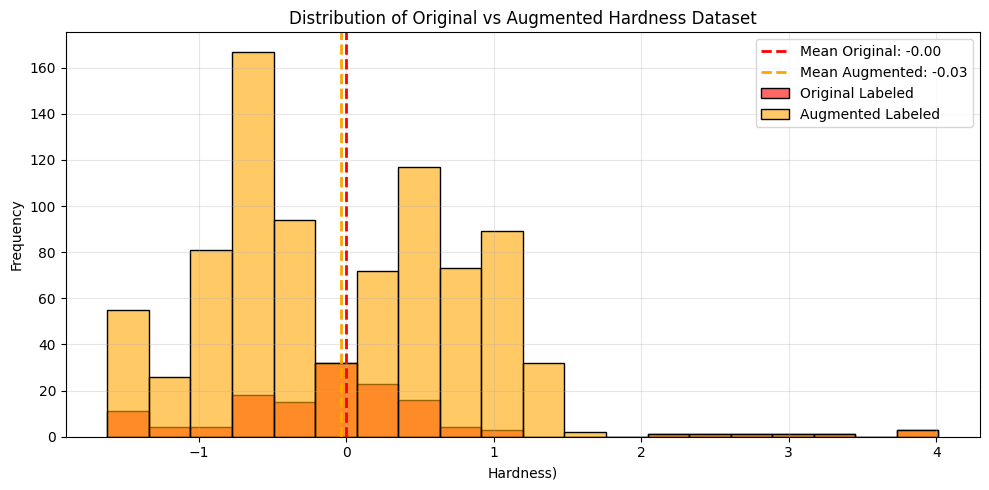

In [32]:
plt.figure(figsize=(10, 5))

# Original labeled data
sns.histplot(y_labeled, bins=20, color='red', edgecolor='k', alpha=0.6, label='Original Labeled')

# Augmented labeled data
sns.histplot(y_labeled_current, bins=20, color='orange', edgecolor='k', alpha=0.6, label='Augmented Labeled')

# Mean lines
plt.axvline(y_labeled.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean Original: {y_labeled.mean():.2f}")
plt.axvline(y_labeled_current.mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean Augmented: {y_labeled_current.mean():.2f}")

plt.xlabel('Hardness)')
plt.ylabel('Frequency')
plt.title('Distribution of Original vs Augmented Hardness Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

